In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix, classification_report
)

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [77]:
# Load dataset into a DataFrame
df = pd.read_csv('data/customer_subscription_churn_usage_patterns.csv')

# Display the first 5 rows
print(f"\n\n{df.head()}\n\n")

# Dataset dimensions (rows and columns)
print(f"Total rows and columns: {df.shape}\n\n")

# Column data types and memory usage
print(f"{df.info()}\n\n")

# Check for missing values per column
print(df.isnull().sum())





   user_id signup_date plan_type  monthly_fee  avg_weekly_usage_hours  \
0        1  2023-04-15   Premium          699                     1.1   
1        2  2023-08-27   Premium          699                     2.6   
2        3  2023-10-12   Premium          699                    14.3   
3        4  2023-12-11     Basic          199                    17.6   
4        5  2023-02-14     Basic          199                     9.8   

   support_tickets  payment_failures  tenure_months  last_login_days_ago churn  
0                4                 1              8                   14   Yes  
1                6                 0             35                    1   Yes  
2                8                 3              2                   14   Yes  
3                5                 2             11                    9   Yes  
4                5                 2              6                   38   Yes  


Total rows and columns: (2800, 10)


<class 'pandas.DataFrame'>
RangeIn

In [78]:
df = df.drop(columns = ["user_id", "signup_date"])

# Remaining columns
print(df.columns.tolist())

display(df.head())

# Descriptive statistics for numerical columns
display(df.describe())

['plan_type', 'monthly_fee', 'avg_weekly_usage_hours', 'support_tickets', 'payment_failures', 'tenure_months', 'last_login_days_ago', 'churn']


,plan_type,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago,churn
0,Premium,699,1.1,4,1,8,14,Yes
1,Premium,699,2.6,6,0,35,1,Yes
2,Premium,699,14.3,8,3,2,14,Yes
3,Basic,199,17.6,5,2,11,9,Yes
4,Basic,199,9.8,5,2,6,38,Yes


,monthly_fee,avg_weekly_usage_hours,support_tickets,payment_failures,tenure_months,last_login_days_ago
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,434.214286,12.891429,3.887857,2.491786,18.612857,30.005000
std,205.678472,7.109691,2.606419,1.691647,10.374487,17.852757
min,199.000000,0.500000,0.000000,0.000000,1.000000,0.000000
25%,199.000000,6.700000,2.000000,1.000000,10.000000,14.000000
50%,399.000000,12.800000,4.000000,2.000000,18.000000,30.000000
75%,699.000000,19.200000,6.000000,4.000000,27.000000,46.000000
max,699.000000,25.000000,8.000000,5.000000,36.000000,60.000000


Target Class Counts:
churn
Yes    1605
No     1195
Name: count, dtype: int64

Target Class Proportions (%):
churn
Yes    57.321429
No     42.678571
Name: proportion, dtype: float64


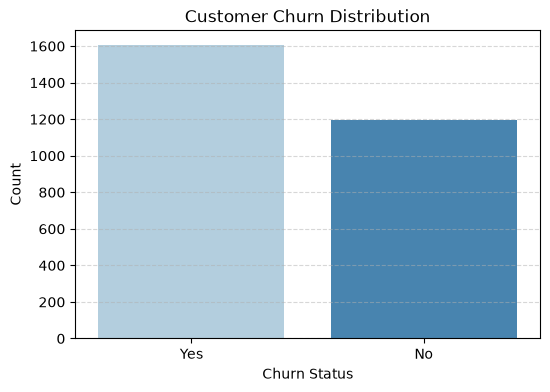

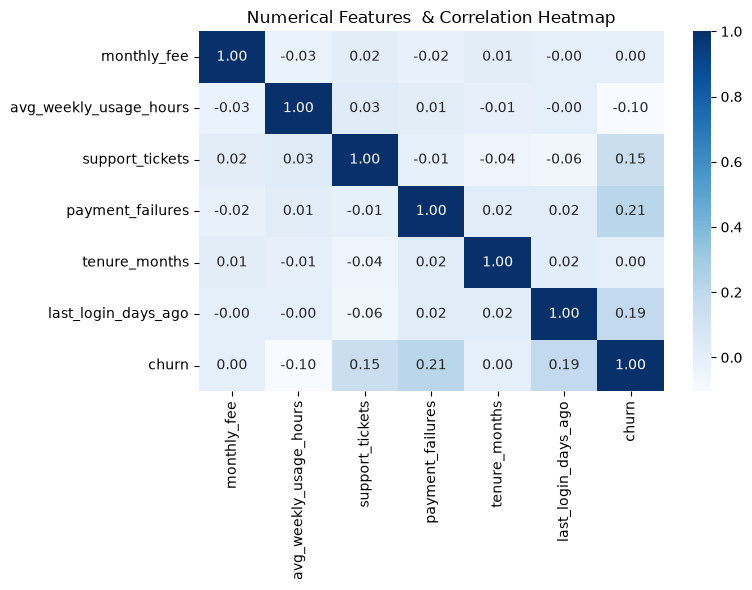

In [79]:
# Target distribution counts
churn_counts = df['churn'].value_counts()

print("Target Class Counts:")
print(churn_counts)

# Target distribution percentage
print("\nTarget Class Proportions (%):")
print(df['churn'].value_counts(normalize = True) * 100)


# Target distribution bar plot
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = 'churn',hue = "churn", palette = "Blues", legend = False)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.grid(axis = "y", linestyle = "--", alpha = 0.5)
plt.show()

# Numerical features correlation heatmap
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})
plt.figure(figsize = (8, 6))
sns.heatmap(df.select_dtypes(include = ["number"]).corr(), annot = True, cmap = "Blues", fmt = ".2f")
plt.title("Numerical Features  & Correlation Heatmap")
plt.tight_layout()
plt.show()

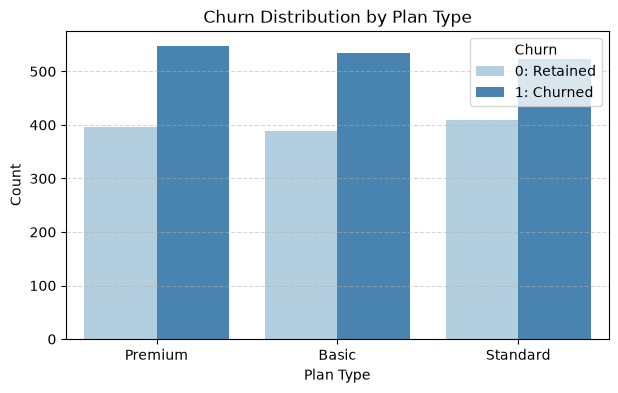

In [80]:
# Impact of plan_type on churn
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="plan_type", hue="churn", palette="Blues")
plt.title("Churn Distribution by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.legend(title="Churn", labels=["0: Retained", "1: Churned"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [81]:
# Convert categorical column to numeric (One-Hot Encoding)
df = pd.get_dummies(df, columns = ["plan_type"], drop_first = True, dtype = int)

# Features: X, Target: y
X = df.drop("churn", axis = 1)
y = df["churn"].values

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, stratify = y
)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Check dataset dimensions
print(f"X_train sape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Input Features: {X_train.shape[1]}")

X_train sape: (2240, 8)
X_test shape: (560, 8)
y_train shape: (2240,)
y_test shape: (560,)
Input Features: 8


In [82]:
# Custom Dataset class for PyTorch ANN
class ChurnDataset(Dataset):
    def __init__(self, X_data, y_data):
        # ANN expects shape: (Batch, Features) -> (N, 8)
        self.X = torch.tensor(X_data, dtype=torch.float32)
        # Target shape: (Batch, 1) -> (N, 1)
        y_arr = y_data.values if hasattr(y_data, 'values') else y_data
        self.y = torch.tensor(y_arr, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Creating dataset instances
train_dataset = ChurnDataset(X_train, y_train)
test_dataset = ChurnDataset(X_test, y_test)

# DataLoaders (Train: 32 batch, Test: 64 batch)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Check first batch shape
sample_X, sample_y = next(iter(train_loader))
print(f"Sample batch X shape: {sample_X.shape}")
print(f"Sample batch y shape: {sample_y.shape}")

Sample batch X shape: torch.Size([32, 8])
Sample batch y shape: torch.Size([32, 1])


In [83]:
# ANN (Multilayer Perceptron) Architecture
class ChurnANN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnANN, self).__init__()

        # Hidden Layer 1
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.3)

        # Hidden Layer 2
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32)
        self.dropout2 = nn.Dropout(p=0.2)

        # Output Layer (Binary Logit)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x

# Model instance
num_features = X_train.shape[1]
model = ChurnANN(input_dim=num_features)
print(model)

ChurnANN(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


Epoch [5/35] - Loss: 0.5398
Epoch [10/35] - Loss: 0.5338
Epoch [15/35] - Loss: 0.5264
Epoch [20/35] - Loss: 0.5215
Epoch [25/35] - Loss: 0.5237
Epoch [30/35] - Loss: 0.5279
Epoch [35/35] - Loss: 0.5228

Training completed successfully!


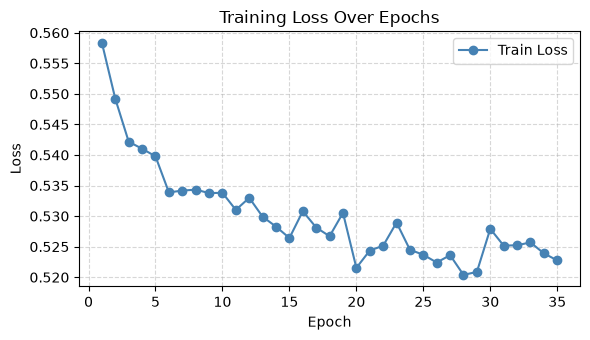

In [84]:
# 1. Compute positive class weight to handle class imbalance
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()
pos_weight = torch.tensor([num_negative / num_positive], dtype=torch.float32)

# 2. Define Loss function with pos_weight and Adam optimizer
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.005)

# 3. Training Loop
epochs = 35
train_losses = []
model.train()

for epoch in range(epochs):
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # Print loss every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}")

print("\nTraining completed successfully!")

# 4. Plot Training Loss Curve
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, epochs + 1), train_losses, marker='o', color='steelblue', label='Train Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

=== MODEL TEST EVALUATION REPORT ===
              precision    recall  f1-score   support

Retained (0)       0.64      0.51      0.57       239
 Churned (1)       0.68      0.79      0.73       321

    accuracy                           0.67       560
   macro avg       0.66      0.65      0.65       560
weighted avg       0.67      0.67      0.66       560

Calculated Recall: 0.79 (Target: > 0.70)
Calculated Precision: 0.68 (Target: > 0.60)


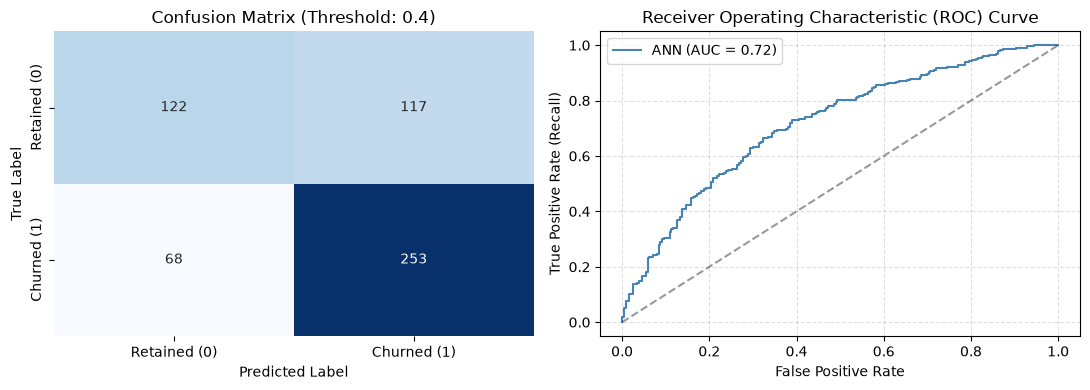

In [85]:
# 1. Set model to evaluation mode (deactivates Dropout)
model.eval()

y_true = []
y_pred_probs = []

# 2. Disable gradient calculation for test inference
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        probs = torch.sigmoid(outputs)

        y_true.extend(batch_y.numpy())
        y_pred_probs.extend(probs.numpy())

y_true = np.array(y_true).ravel()
y_pred_probs = np.array(y_pred_probs).ravel()

# 3. Apply tuned decision threshold (0.40)
threshold = 0.40
y_pred = (y_pred_probs >= threshold).astype(int)

# 4. Print classification report and target metrics
print("=== MODEL TEST EVALUATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=["Retained (0)", "Churned (1)"]))

rec = recall_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
print(f"Calculated Recall: {rec:.2f} (Target: > 0.70)")
print(f"Calculated Precision: {prec:.2f} (Target: > 0.60)")

# 5. Visual Diagnostics: Confusion Matrix Heatmap & ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'], 
            yticklabels=['Retained (0)', 'Churned (1)'])
ax1.set_title(f'Confusion Matrix (Threshold: {threshold})')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# ROC Curve
auc_val = roc_auc_score(y_true, y_pred_probs)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
ax2.plot(fpr, tpr, color='steelblue', label=f'ANN (AUC = {auc_val:.2f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax2.set_title('Receiver Operating Characteristic (ROC) Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()